## Load Dataset

In [1]:
import pandas as pd

# Load raw dataset
df = pd.read_csv("car_dataset_before_preprocessed.csv")

# Show first few rows
df.head()

,Price (M),Brand,Model,Year,Mileage (km),Fuel type,Engine capacity (CC),Transmission
0,9.85,Toyota,Axio,2015,231000,Hybrid,1500,Automatic
1,3.65,Nissan,Sunny,1998,140000,Petrol,650,Automatic
2,153.00,Land Rover,Range Rover,2025,0,Hybrid,3000,Automatic
3,10.70,Toyota,Raize,2020,75000,Petrol,1000,Automatic
4,16.80,Toyota,Yaris Ativ,2025,0,Petrol,1200,Automatic


## Preporcessing

### Check Missing values

In [69]:
# Check shape and column names
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

# Check missing values
df.isna().sum()

Shape: (976, 8)
Columns: ['Price (M)', 'Brand', 'Model', 'year', 'Mileage (km)', 'Fuel type', 'Engine capacity (CC)', 'Transmission']


Price (M)               0
Brand                   0
Model                   0
year                    0
Mileage (km)            0
Fuel type               0
Engine capacity (CC)    0
Transmission            0
dtype: int64

### Standardise Text Categories

In [70]:
# Clean text columns (remove extra spaces and make consistent text)
text_cols = ["Brand", "Model", "Fuel type", "Transmission"]

for col in text_cols:
    df[col] = df[col].astype(str).str.strip()

# Standardise formatting
df["Brand"] = df["Brand"].str.title()
df["Model"] = df["Model"].str.title()
df["Fuel type"] = df["Fuel type"].str.title()
df["Transmission"] = df["Transmission"].str.title()

# Check unique values (optional)
df[text_cols].nunique()

Brand            41
Model           231
Fuel type         5
Transmission      3
dtype: int64

In [2]:
# Check unique categories after standardising
for col in ["Brand", "Model", "Fuel type", "Transmission"]:
    print(f"\n{col} unique values:")
    print(df[col].unique())


Brand unique values:
['Toyota' 'Nissan' 'Land Rover' 'Mercedes Benz' 'Mitsubishi' 'Honda'
 'Hyundai' 'Ford' 'Suzuki' 'Audi' 'Kia' 'BMW' 'Daihatsu' 'Maruti Suzuki'
 'BAIC' 'Mahindra' 'Volkswagen' 'Peugeot' 'MG' 'Micro' 'Perodua' 'Subaru'
 'Jeep' 'Mazda' 'Zotye' 'Jaguar' 'Porsche' 'DFSK' 'Bentley' 'Chery'
 'Chevrolet' 'Fiat' 'Other brand' 'Chrysler' 'Tata' 'Maruti' 'Isuzu' 'BYD'
 'Ssang Yong' 'Skoda' 'Lexus']

Model unique values:
['Axio' 'Sunny' 'Range Rover' 'Raize' 'Yaris Ativ' 'Serena' 'Premio'
 'RAV4' 'Corolla' 'Land Cruiser Sahara' 'S300' 'Montero' 'Defender' 'C200'
 'Vezel' 'Grand i10' 'Matrix' 'Urban Cruiser' 'Discovery' 'Aqua'
 'Land Cruiser Prado' 'Raptor Ranger' 'Swift' 'A3' 'Other Model' 'Focus'
 'Esquire' 'Wagon R' '740Le' 'Elantra' 'Lancer' 'Maruti' 'Civic' 'Hilux'
 'City' 'Mira' 'Rush' 'Tucson' 'Wagon R ZX' 'Alto' 'Pixis' '800'
 'Yaris Cross' 'Wagon R FX' 'Fit' 'A4' 'Yaris' '318i' 'C350' 'E180'
 'Spacia' 'i8' 'Vitz' 'S350' 'Hustler' 'Alphard' '740e' 'A5' 'X55 II'
 'KUV 10

### Outlier Handling: Check Distributions

In [3]:
# Quick summary to see min/max and percentiles
df[["Price (M)", "Mileage (km)", "Engine capacity (CC)"]].describe(percentiles=[0.01, 0.05, 0.95, 0.99])

,Price (M),Mileage (km),Engine capacity (CC)
count,976.000000,976.000000,976.000000
mean,20.058204,60993.890369,1543.191598
std,24.958836,70481.659589,773.285999
min,0.720000,0.000000,1.000000
1%,2.075000,0.000000,173.750000
5%,3.588750,0.000000,650.000000
50%,12.500000,25500.000000,1500.000000
95%,63.500000,195000.000000,3000.000000
99%,127.250000,260793.750000,4200.000000
max,275.000000,382000.000000,4660.000000


### Clip Extreme Values (1%–99%)

In [4]:
# Work on a copy
df_clean = df.copy()

cols_to_clip = ["Price (M)", "Mileage (km)", "Engine capacity (CC)"]

for col in cols_to_clip:
    low = df_clean[col].quantile(0.01)
    high = df_clean[col].quantile(0.99)
    df_clean[col] = df_clean[col].clip(lower=low, upper=high)

print("Done: Outliers clipped using 1% and 99% quantiles.")
df_clean[cols_to_clip].describe(percentiles=[0.01, 0.99])

Done: Outliers clipped using 1% and 99% quantiles.


,Price (M),Mileage (km),Engine capacity (CC)
count,976.000000,976.000000,976.000000
mean,19.491443,60449.589652,1541.796619
std,21.124367,68630.088195,761.533980
min,2.075000,0.000000,173.750000
1%,2.093750,0.000000,178.437500
50%,12.500000,25500.000000,1500.000000
99%,124.062500,260198.437500,4200.000000
max,127.250000,260793.750000,4200.000000


### Count Type–Model Frequency

In [5]:
# Step 1: Count occurrences of each Brand-Model pair
brand_model_counts = df.groupby(["Brand", "Model"]).size().reset_index(name="Count")

# Step 2: Identify rare pairs (Count < 10)
rare_pairs = brand_model_counts[brand_model_counts["Count"] < 10]

# Step 3: Sort by count (smallest first)
rare_pairs = rare_pairs.sort_values(by="Count")

# Show rare Brand-Model pairs
print("Rare Brand-Model Pairs:")
display(rare_pairs)

# Step 4: Frequency distribution (1,2,3,... counts)
frequency_distribution = rare_pairs["Count"].value_counts().sort_index()

print("\nFrequency Distribution:")
display(frequency_distribution)

Rare Brand-Model Pairs:


,Brand,Model,Count
1,Audi,A4,1
2,Audi,A5,1
6,Audi,Q5,1
5,Audi,Q4 E-Tron S Line,1
8,Audi,e-tron,1
...,...,...,...
91,Land Rover,Defender,9
53,Ford,Raptor Ranger,9
44,Daihatsu,Taft,9
203,Toyota,Aqua,9



Frequency Distribution:


Count
1    121
2     33
3     25
4     13
5      9
6      6
7      2
8      3
9      5
Name: count, dtype: int64

## Remove Type–Model Pairs with Count ≤ 3

In [75]:
# Get Brand-Model pairs with Count <= 3
remove_pairs = rare_pairs[rare_pairs["Count"] <= 3][["Brand", "Model"]]

# Remove them from original dataframe
df_filtered = df.merge(
    remove_pairs,
    on=["Brand", "Model"],
    how="left",
    indicator=True
)

# Keep only rows NOT in remove_pairs
df_filtered = df_filtered[df_filtered["_merge"] == "left_only"].drop(columns=["_merge"])

# Check size
print("Original shape:", df.shape)
print("Filtered shape:", df_filtered.shape)

Original shape: (976, 8)
Filtered shape: (714, 8)


## Define Features for CatBoost

In [76]:
from sklearn.model_selection import train_test_split

# Use filtered dataset (important)
df = df_filtered.copy()

# Define inputs (X) and output (y)
X = df.drop(columns=["Price (M)"])
y = df["Price (M)"]

# Identify categorical columns
cat_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Categorical columns:", cat_features)

# Train-test split (70:30) with random_state=42
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

# Show shapes
print("X_train shape:", X_train.shape)  
print("y_train shape:", y_train.shape)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

Categorical columns: ['Brand', 'Model', 'Fuel type', 'Transmission']
X_train shape: (499, 7)
y_train shape: (499,)
X_test shape: (215, 7)
y_test shape: (215,)


## Grid Search Code for CatBoost

In [ ]:
from catboost import CatBoostRegressor
from sklearn.model_selection import GridSearchCV

# Base CatBoost model
cat_model = CatBoostRegressor(
    loss_function="RMSE",
    random_seed=42,
    verbose=0
)

# Parameter grid (what we want to test)
param_grid = {
    "iterations": [300, 400, 500],
    "depth": [6, 8, 10, 12],
    "learning_rate": [0.01, 0.03, 0.05, 0.1]
}

# Grid Search
grid_search = GridSearchCV(
    estimator=cat_model,
    param_grid=param_grid,
    scoring="r2",
    cv=4,           # 3-fold cross validation
    n_jobs=-1       # Use all CPU cores
)

# Run Grid Search
grid_search.fit(
    X_train,
    y_train,
    cat_features=cat_features
)

# Best model
best_model = grid_search.best_estimator_

# Best parameters
print("Best Parameters:")
print(grid_search.best_params_)

# Best CV score
print("Best CV R2 Score:")
print(grid_search.best_score_)

In [77]:
import numpy as np
from catboost import CatBoostRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Train model
best_cat = CatBoostRegressor(
    iterations=300,
    depth=8,
    learning_rate=0.03,
    loss_function="RMSE",
    random_seed=42,
    verbose=0
)

best_cat.fit(X_train, y_train, cat_features=cat_features)

# Predict
y_train_pred = best_cat.predict(X_train)
y_test_pred = best_cat.predict(X_test)

# --- Base metrics ---
train_r2 = r2_score(y_train, y_train_pred)
test_r2  = r2_score(y_test, y_test_pred)

train_mse = mean_squared_error(y_train, y_train_pred)
test_mse  = mean_squared_error(y_test, y_test_pred)

train_rmse = np.sqrt(train_mse)
test_rmse  = np.sqrt(test_mse)

train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae  = mean_absolute_error(y_test, y_test_pred)

# --- Normalised metrics ---
# NMSE = MSE / Var(y)
train_nmse = train_mse / np.var(y_train)
test_nmse  = test_mse  / np.var(y_test)

# NMAE = MAE / Mean(y)
train_nmae = train_mae / np.mean(y_train)
test_nmae  = test_mae  / np.mean(y_test)

# Print results
print("Train R2 :", train_r2)
print("Test R2  :", test_r2)

print("Train NMSE:", train_nmse)
print("Test NMSE :", test_nmse)

print("Train NMAE:", train_nmae)
print("Test NMAE :", test_nmae)

Train R2 : 0.968076986759996
Test R2  : 0.9400753387451193
Train NMSE: 0.03192301324000399
Test NMSE : 0.059924661254880725
Train NMAE: 0.10659434835297625
Test NMAE : 0.13836334903011177


## Scatter plots

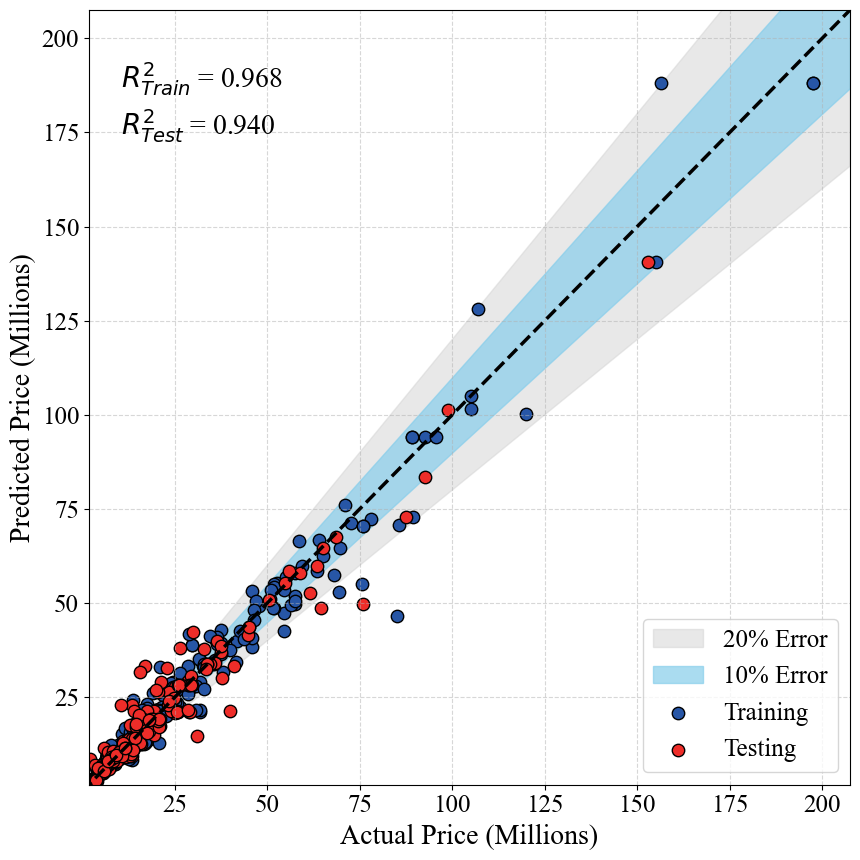

In [78]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score

# Set global font
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 20


# Convert to numpy
y_train_np = np.array(y_train)
y_test_np = np.array(y_test)

y_train_pred_np = np.array(y_train_pred)
y_test_pred_np = np.array(y_test_pred)

# R2
r2_train = r2_score(y_train_np, y_train_pred_np)
r2_test  = r2_score(y_test_np, y_test_pred_np)

# Limits
min_val = min(y_train_np.min(), y_test_np.min())
max_val = max(y_train_np.max(), y_test_np.max())+10

x = np.linspace(0, max_val, 300)

# Error bands
err10_upper = 1.10 * x
err10_lower = 0.90 * x

err20_upper = 1.20 * x
err20_lower = 0.80 * x


# Plot
plt.figure(figsize=(9, 9))

# 20% band
plt.fill_between(
    x, err20_lower, err20_upper,
    color="lightgrey", alpha=0.5,
    label="20% Error"
)

# 10% band
plt.fill_between(
    x, err10_lower, err10_upper,
    color="skyblue", alpha=0.7,
    label="10% Error"
)

# X=Y line
plt.plot(x, x, "k--", linewidth=2.5)

# Scatter
plt.scatter(
    y_train_np, y_train_pred_np,
    c="#2756a6", edgecolors="black",
    s=80, label="Training"
)

plt.scatter(
    y_test_np, y_test_pred_np,
    c="#ee2d29", edgecolors="black",
    s=80, label="Testing"
)

# Labels
plt.xlabel("Actual Price (Millions)", fontsize=20)
plt.ylabel("Predicted Price (Millions)", fontsize=20)

# R2 text
plt.text(
    0.05*max_val, 0.90*max_val,
    rf"$R^2_{{Train}}$ = {r2_train:.3f}",
    fontsize=20
)

plt.text(
    0.05*max_val, 0.84*max_val,
    rf"$R^2_{{Test}}$ = {r2_test:.3f}",
    fontsize=20
)

# Limits
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)

# Ticks
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

# Grid + legend
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(fontsize=18)

plt.tight_layout()


plt.show()

## Identify Extreme Errors (> 20%)

### Create Result DataFrames (Actual, Predicted, Error)

In [79]:
import pandas as pd
import numpy as np

# ---- TRAIN RESULTS ----
train_results = X_train.copy()

train_results["Actual"] = y_train.values
train_results["Predicted"] = y_train_pred
train_results["Abs_Error"] = np.abs(train_results["Actual"] - train_results["Predicted"])
train_results["Rel_Error_%"] = (train_results["Abs_Error"] / train_results["Actual"]) * 100


# ---- TEST RESULTS ----
test_results = X_test.copy()

test_results["Actual"] = y_test.values
test_results["Predicted"] = y_test_pred
test_results["Abs_Error"] = np.abs(test_results["Actual"] - test_results["Predicted"])
test_results["Rel_Error_%"] = (test_results["Abs_Error"] / test_results["Actual"]) * 100

### Extract Extreme Cases

In [81]:
# Train: errors > 20%
train_extreme = train_results[train_results["Rel_Error_%"] > 20]

# Test: errors > 20%
test_extreme = test_results[test_results["Rel_Error_%"] > 20]

print("Train samples >20% error:", len(train_extreme))
print("Test samples  >20% error:", len(test_extreme))

print("Train percentage:",
      round(100 * len(train_extreme) / len(train_results), 2), "%")

print("Test percentage:",
      round(100 * len(test_extreme) / len(test_results), 2), "%")


Train samples >20% error: 85
Test samples  >20% error: 57
Train percentage: 17.03 %
Test percentage: 26.51 %


### Show Worst Predictions

In [82]:
### Train
train_extreme_sorted = train_extreme.sort_values(
    by="Rel_Error_%", ascending=False
)

train_extreme_sorted.head(10)

,Brand,Model,year,Mileage (km),Fuel type,Engine capacity (CC),Transmission,Actual,Predicted,Abs_Error,Rel_Error_%
274,Toyota,Corolla,1997,330000,Diesel,2000,Automatic,2.95,6.908011,3.958011,134.169877
577,Toyota,Land Cruiser Prado,2004,172500,Petrol,2700,Automatic,13.75,24.318704,10.568704,76.863305
24,Toyota,Rav4,2008,145000,Petrol,2000,Automatic,7.75,12.229008,4.479008,57.793653
303,Toyota,Land Cruiser Sahara,2000,147250,Petrol,4660,Automatic,21.00,32.925520,11.925520,56.788193
209,Mitsubishi,Ek Wagon,2025,5000,Petrol,660,Automatic,6.80,9.952431,3.152431,46.359280
567,Honda,Fit,2013,64000,Hybrid,1300,Automatic,6.75,9.878883,3.128883,46.353824
629,Mitsubishi,Ek Wagon,2024,4000,Petrol,660,Automatic,6.55,9.571933,3.021933,46.136378
159,Audi,Q2,2017,90000,Petrol,1000,Automatic,11.50,16.788162,5.288162,45.984014
746,Nissan,Sunny,2021,184177,Petrol,1466,Manual,4.65,6.771884,2.121884,45.631918
124,Toyota,Land Cruiser Prado,2011,188000,Diesel,3000,Automatic,28.80,41.903539,13.103539,45.498398


## SHAP

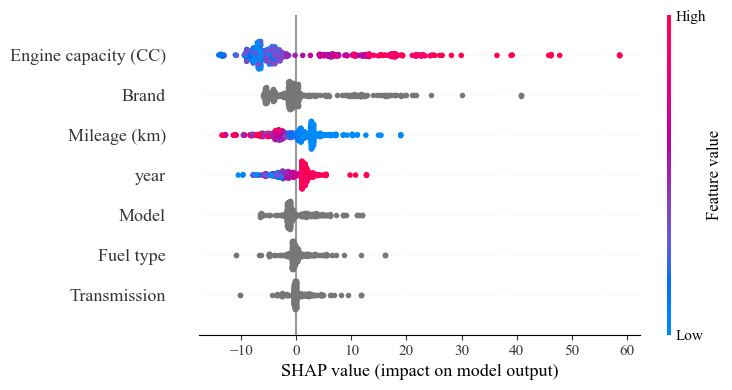

In [83]:
import shap
import matplotlib.pyplot as plt
from catboost import Pool

# Create Pool (important for SHAP)
train_pool = Pool(X_train, y_train, cat_features=cat_features)

# Get SHAP values (last column is base value)
shap_values = best_cat.get_feature_importance(train_pool, type="ShapValues")

# Remove last column (base value)
shap_values = shap_values[:, :-1]

# Beeswarm plot
shap.summary_plot(shap_values, X_train, show=True)